In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [27]:
df = pd.read_csv('/content/loan_approval_dataset.csv')
df


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [29]:
df = df.drop(columns='loan_id')

In [30]:
df.isnull().sum()

,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0
luxury_assets_value,0


In [31]:
df.describe()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [32]:
df.columns

Index([' no_of_dependents', ' education', ' self_employed', ' income_annum',
       ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
x = df.drop(columns=' loan_status')
y = df[' loan_status']

In [35]:

df[' loan_status'] = df[' loan_status'].str.strip().map({'Approved': 1, 'Rejected': 0})
corr = df.corr(numeric_only=True)[' loan_status'].sort_values(ascending=False)
corr

,loan_status
loan_status,1.000000
cibil_score,0.770518
loan_amount,0.016150
commercial_assets_value,0.008246
bank_asset_value,-0.006778
residential_assets_value,-0.014367
income_annum,-0.015189
luxury_assets_value,-0.015465
no_of_dependents,-0.018114
loan_term,-0.113036


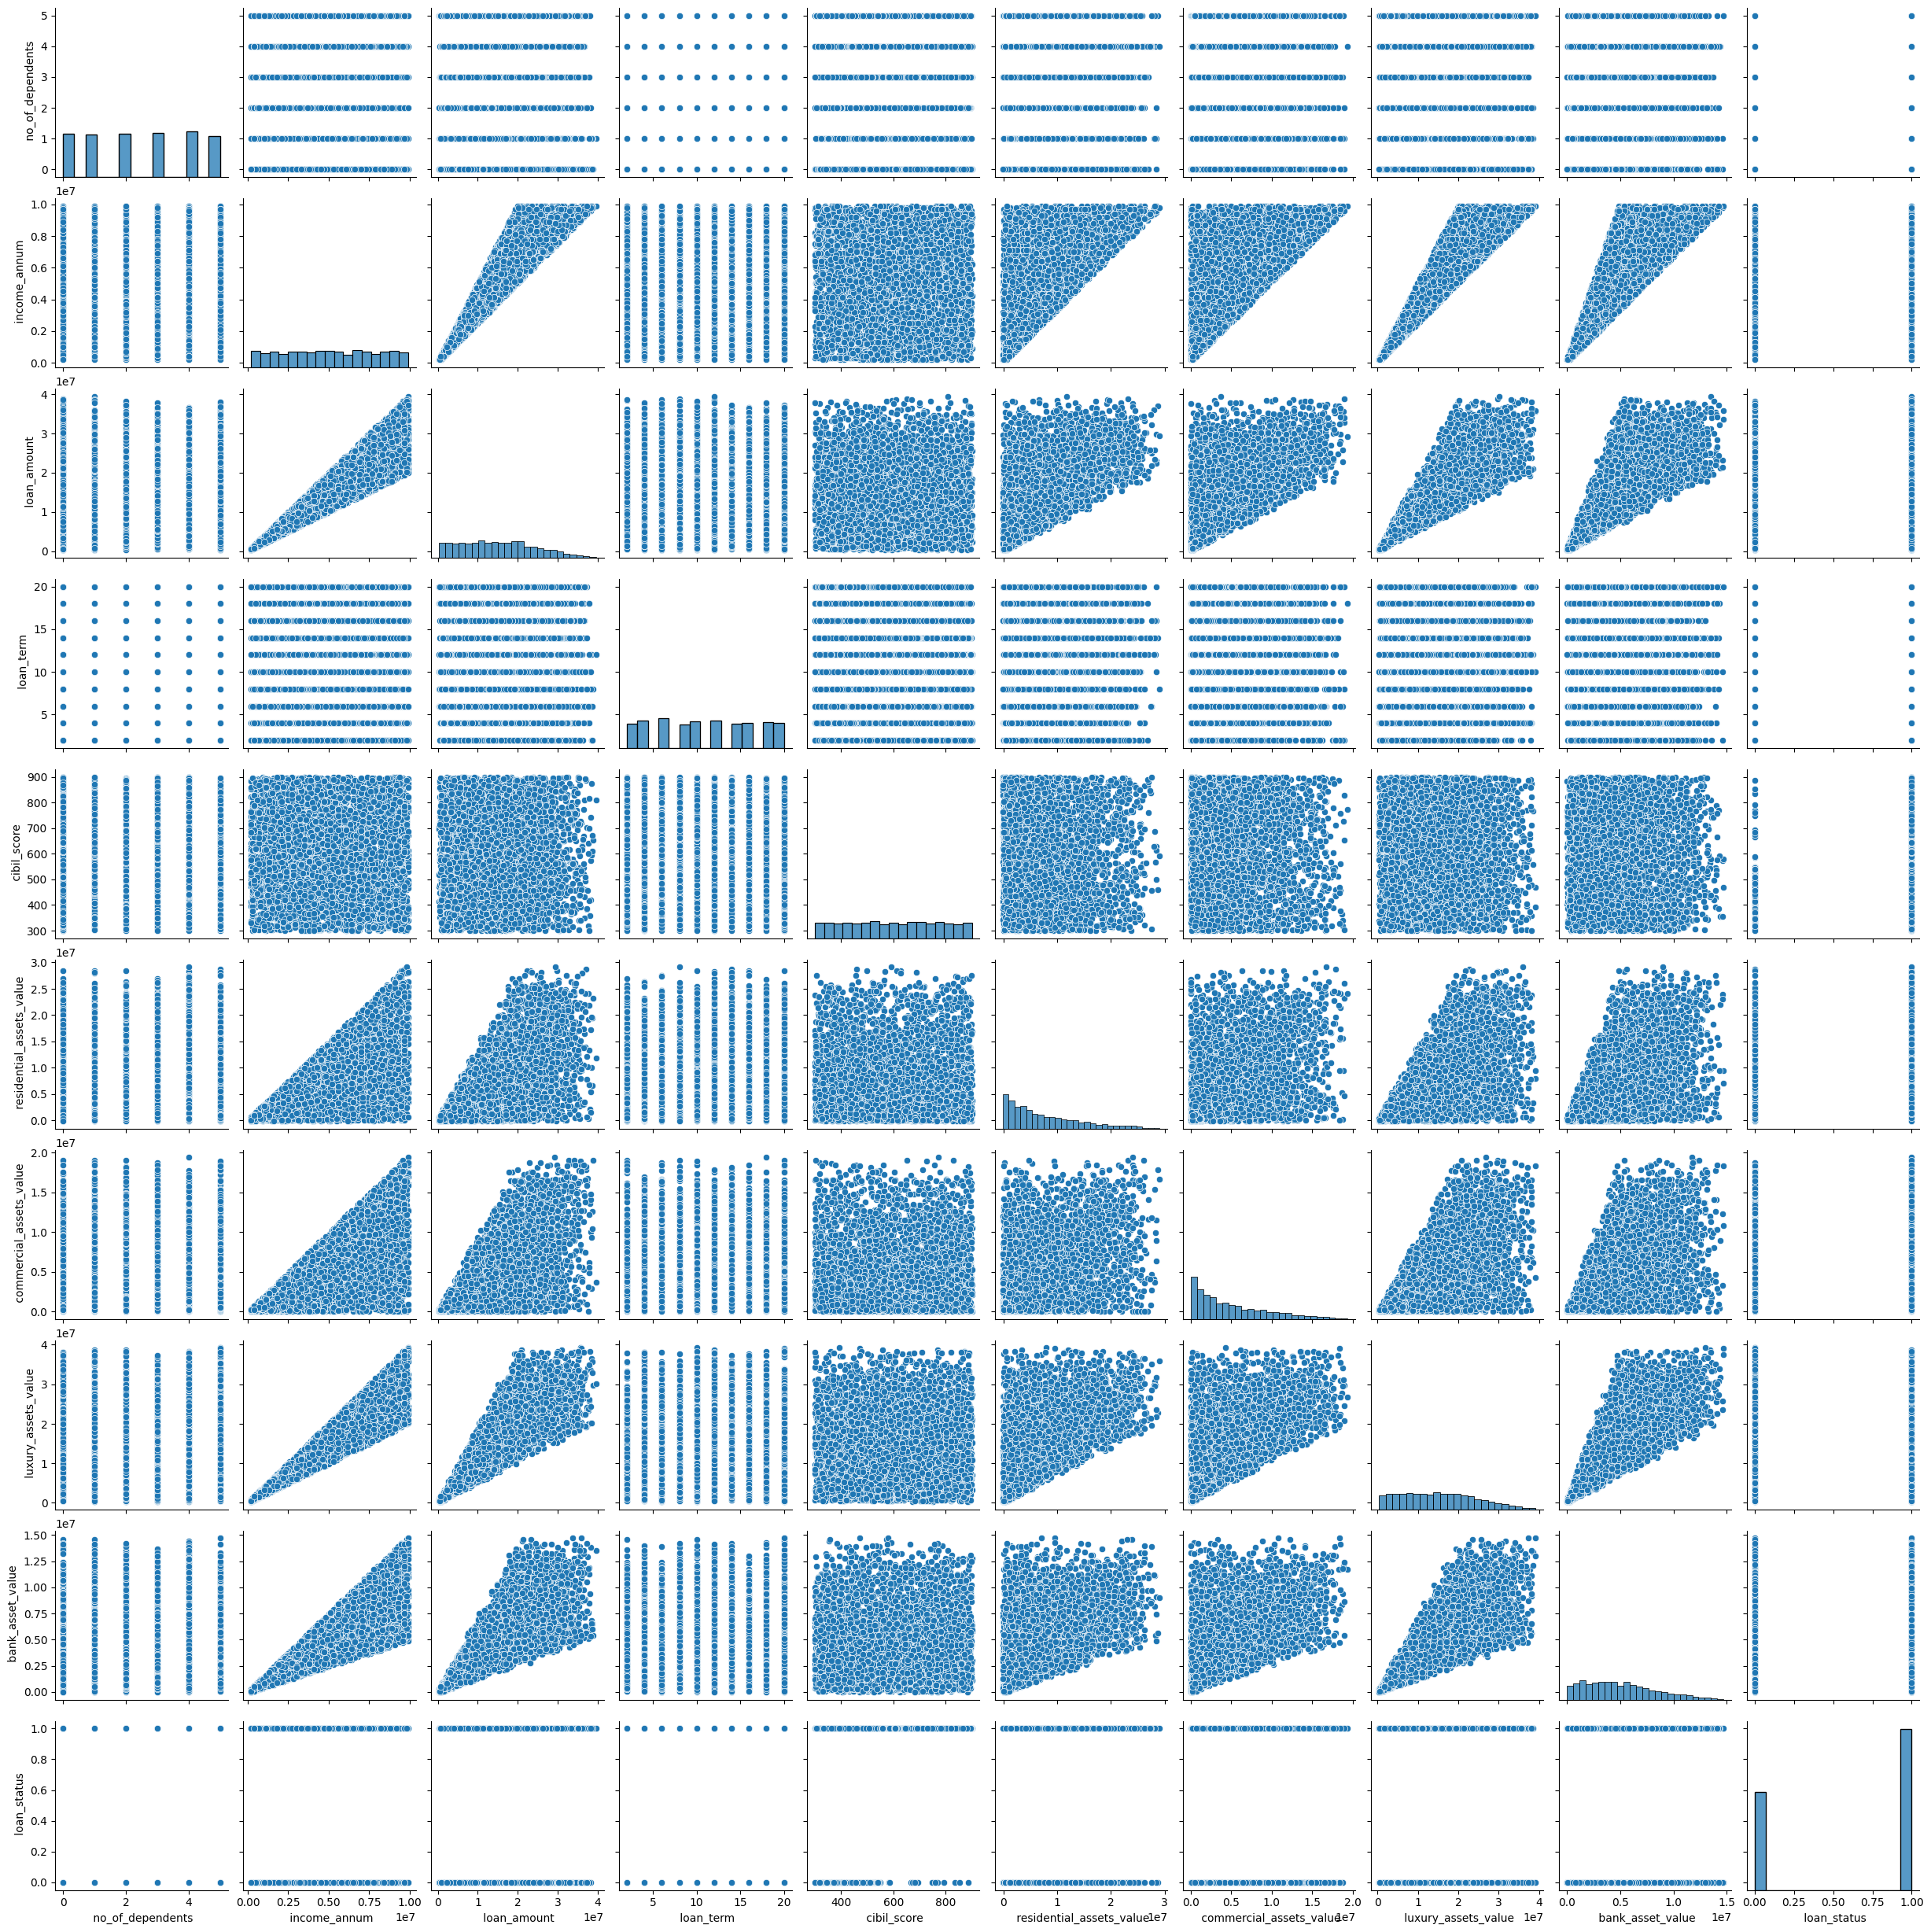

In [36]:
sns.pairplot(df)

In [37]:
numerical_cols = x.select_dtypes(include=['int64', 'float64']).columns
catagorical_cols = x.select_dtypes(include=['object']).columns


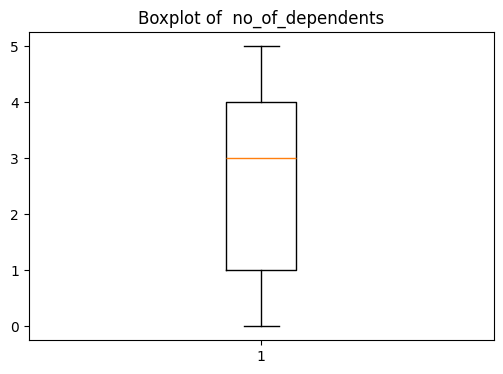

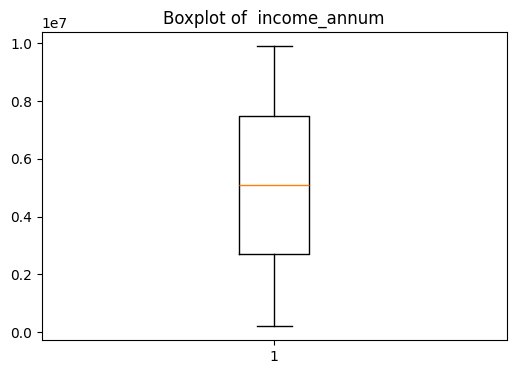

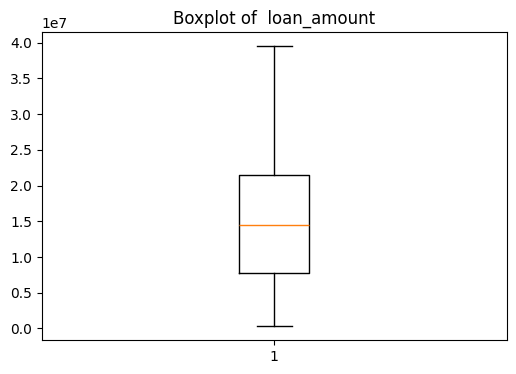

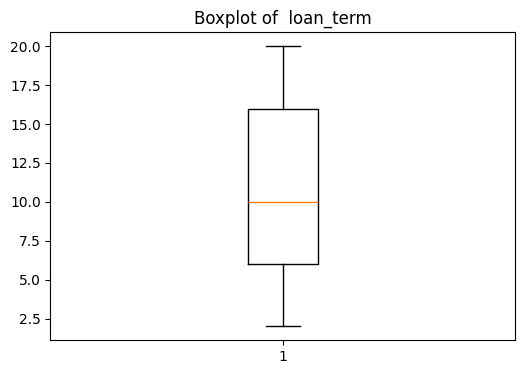

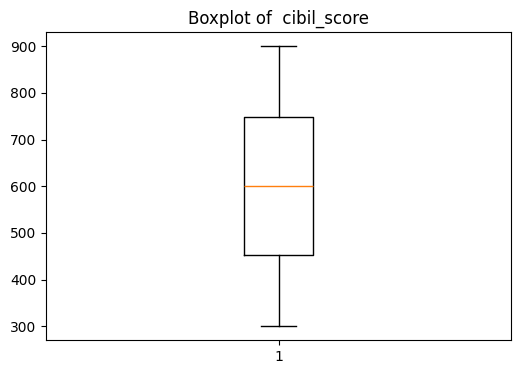

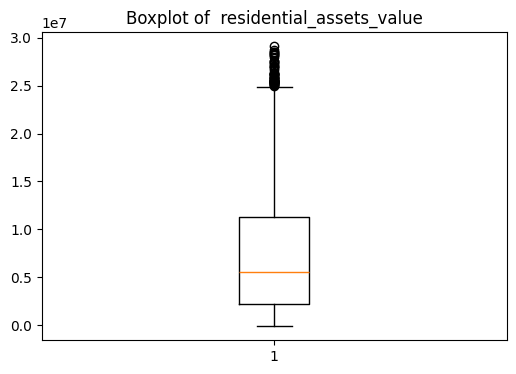

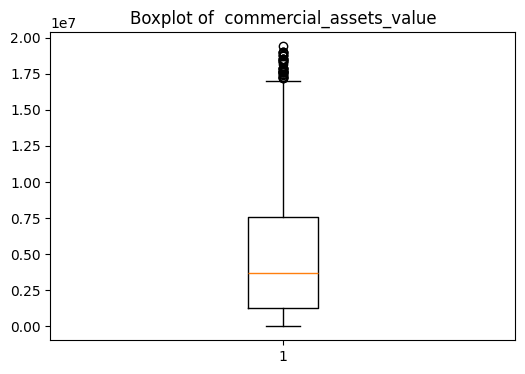

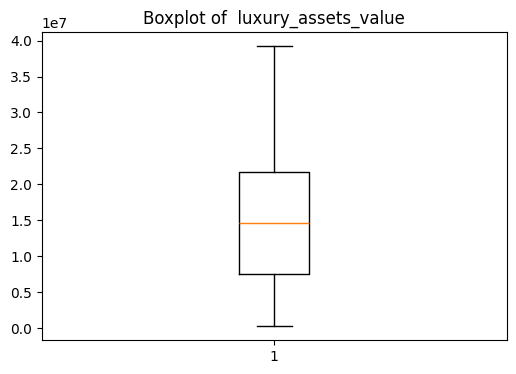

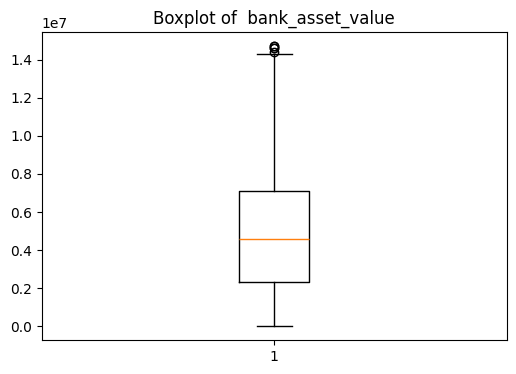

In [38]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(x[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [39]:
outliers_col = [' residential_assets_value', ' commercial_assets_value', ' bank_asset_value', ' loan_status']

In [40]:
def handle_outliers(df, columns, factor=1.5):
  df_copy = df.copy()
  outlier_info = {}
  for col in columns:
      Q1 = df[col].quantile(0.25)
      q3 = df[col].quantile(0.75)
      IQR = q3 - Q1
      lower_bound = Q1 - factor * IQR
      upper_bound = q3 + factor * IQR

      mask = (df[col] < lower_bound) | (df[col] > upper_bound)
      outliers = df[col][mask]

      median_value = df[col].median()
      df_copy.loc[mask, col] = median_value

      outlier_info[col] = {
          'outliers': outliers,
          'lower_bound': lower_bound,
          'upper_bound': upper_bound,
          'median_value': median_value
      }
  return df_copy, outlier_info

df_copy, outlier_info = handle_outliers(df, outliers_col)
df_copy, outlier_info

(      no_of_dependents      education self_employed  income_annum  \
 0                    2       Graduate            No       9600000   
 1                    0   Not Graduate           Yes       4100000   
 2                    3       Graduate            No       9100000   
 3                    3       Graduate            No       8200000   
 4                    5   Not Graduate           Yes       9800000   
 ...                ...            ...           ...           ...   
 4264                 5       Graduate           Yes       1000000   
 4265                 0   Not Graduate           Yes       3300000   
 4266                 2   Not Graduate            No       6500000   
 4267                 1   Not Graduate            No       4100000   
 4268                 1       Graduate            No       9200000   
 
       loan_amount  loan_term  cibil_score  residential_assets_value  \
 0        29900000         12          778                   2400000   
 1        1220

In [41]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [42]:
preprocessing = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(), catagorical_cols)
    ]
)

In [43]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'Support Vector Machine': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Naive Bayes': GaussianNB(),
    'Neural Network': MLPClassifier()

}

In [44]:
result = {}
for name, model in models.items():
  model = Pipeline([
      ('preprocessing', preprocessing),
      ('model', model)
  ])
  model.fit(x_train, y_train)
  y_pred = model.predict(x_test)
  accuracy = accuracy_score(y_test, y_pred)
  result[name] = accuracy
  print(f"{name} Accuracy: {accuracy}")
  print(confusion_matrix(y_test, y_pred))


results_df = pd.DataFrame.from_dict(result, orient='index', columns=['Accuracy']).sort_values(
    by="Accuracy", ascending=False
)

print("\n📊 FINAL MODEL COMPARISON")
print(results_df)

Logistic Regression Accuracy: 0.905152224824356
[[498  38]
 [ 43 275]]
Random Forest Accuracy: 0.9718969555035128
[[527   9]
 [ 15 303]]
Support Vector Machine Accuracy: 0.9262295081967213
[[499  37]
 [ 26 292]]
K-Nearest Neighbors Accuracy: 0.8957845433255269
[[483  53]
 [ 36 282]]
Decision Tree Accuracy: 0.9765807962529274
[[526  10]
 [ 10 308]]
Naive Bayes Accuracy: 0.936768149882904
[[502  34]
 [ 20 298]]
Neural Network Accuracy: 0.9484777517564403
[[514  22]
 [ 22 296]]

📊 FINAL MODEL COMPARISON
                        Accuracy
Decision Tree           0.976581
Random Forest           0.971897
Neural Network          0.948478
Naive Bayes             0.936768
Support Vector Machine  0.926230
Logistic Regression     0.905152
K-Nearest Neighbors     0.895785


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [45]:
from sklearn.model_selection import cross_val_score

# Find the model name with the maximum accuracy
best_model_name = max(result, key=result.get)

model = Pipeline([
      ('processing', preprocessing),
      ('regressor', models[best_model_name])
  ])


cv_Accuracy = cross_val_score(
    model,
    x_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
).mean()

print(f'📊 The best model is {best_model_name} with CROSS-VALIDATION:')
print(f"Accuracy: {cv_Accuracy:.4f}")

📊 The best model is Decision Tree with CROSS-VALIDATION:
Accuracy: 0.9742
